# Градиентный спуск на квадратичной функции
В этом ноутбуке мы рассмотрим применение метода градиентного спуска для поиска минимума квадратичной функции f(x, y) = 2.5*x^2 + x*y + 2*y^2 + 12*x + 0.5*y.
Мы подробно разберем каждый шаг, визуализируем траектории и проанализируем влияние параметров на сходимость.

## 1. Импорт библиотек и определение функции
Сначала импортируем необходимые библиотеки и определим функцию и её градиент.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Определяем квадратичную функцию
def f(x, y):
    return 2.5*x**2 + x*y + 2*y**2 + 12*x + 0.5*y

# Определяем градиент функции
def grad_f(x, y):
    df_dx = 5*x + y + 12
    df_dy = x + 4*y + 0.5
    return np.array([df_dx, df_dy])

## 2. Метод градиентного спуска
Определяем функцию градиентного спуска с возможностью настройки шага alpha и точности epsilon.

In [17]:
def gradient_descent(x0, epsilon=1e-3, alpha=0.1, max_iter=1000):
    x = np.array(x0, dtype=float)
    trajectory = [x.copy()]
    num_func_evals = 1
    iter_count = 0

    while iter_count < max_iter:
        grad = grad_f(x[0], x[1])
        x_new = x - alpha * grad
        trajectory.append(x_new.copy())
        num_func_evals += 1
        iter_count += 1
        if np.linalg.norm(x_new - x) < epsilon:
            break
        x = x_new

    return {
        "x_min": x,
        "f_min": f(x[0], x[1]),
        "iterations": iter_count,
        "func_evals": num_func_evals,
        "trajectory": np.array(trajectory)
    }

## 3. Исследование сходимости
Проверяем, как разные начальные приближения и точности влияют на количество итераций и оценку минимума.

In [18]:
epsilons = [1e-1, 1e-3, 1e-5]
x0_list = [[0, 0], [-5, 5], [5, -5]]
alpha = 0.1

results = []
for x0 in x0_list:
    for eps in epsilons:
        res = gradient_descent(x0, epsilon=eps, alpha=alpha)
        results.append({
            "x0": x0,
            "epsilon": eps,
            "iterations": res["iterations"],
            "func_evals": res["func_evals"],
            "x_min": res["x_min"],
            "f_min": res["f_min"]
        })

df = pd.DataFrame(results)
df

,x0,epsilon,iterations,func_evals,x_min,f_min
0,"[0, 0]",0.10000,6,7,"[-2.358275, 0.32796]",-14.789972
1,"[0, 0]",0.00100,17,18,"[-2.498758586583487, 0.4979979022468067]",-14.874991
2,"[0, 0]",0.00001,28,29,"[-2.4999867894715484, 0.4999786256653148]",-14.875000
3,"[-5, 5]",0.10000,8,9,"[-2.6496901, 0.74361495]",-14.736752
4,"[-5, 5]",0.00100,20,21,"[-2.5010610976006205, 0.5017169627193274]",-14.874993
5,"[-5, 5]",0.00001,31,32,"[-2.500011318452873, 0.50001831364954]",-14.875000
6,"[5, -5]",0.10000,10,11,"[-2.3878472205, 0.3224855525]",-14.800440
7,"[5, -5]",0.00100,21,22,"[-2.4988223828805722, 0.49809502757836116]",-14.874992
8,"[5, -5]",0.00001,32,33,"[-2.499987441167587, 0.49997967943400906]",-14.875000


## 4. Визуализация траекторий
Строим линии уровня функции и траектории градиентного спуска для разных начальных точек.

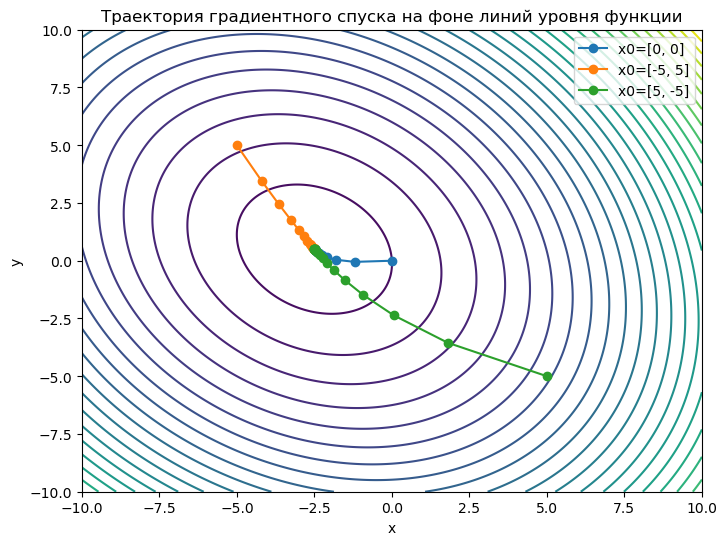

In [19]:
x_range = np.linspace(-10, 10, 400)
y_range = np.linspace(-10, 10, 400)
X, Y = np.meshgrid(x_range, y_range)
Z = f(X, Y)

plt.figure(figsize=(8, 6))
plt.contour(X, Y, Z, levels=30, cmap='viridis')
for x0 in x0_list:
    res = gradient_descent(x0, epsilon=1e-3, alpha=alpha)
    traj = res['trajectory']
    plt.plot(traj[:, 0], traj[:, 1], marker='o', label=f'x0={x0}')
plt.title('Траектория градиентного спуска на фоне линий уровня функции')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

## 5. Анализ результатов
Сравниваем количество итераций и функцию минимума при разных значениях epsilon.

In [20]:
for eps in epsilons:
    subset = df[df['epsilon'] == eps]
    print(f'Точность {eps}:')
    print(subset[['x0', 'iterations', 'func_evals', 'x_min', 'f_min']])

Точность 0.1:
        x0  iterations  func_evals                          x_min      f_min
0   [0, 0]           6           7           [-2.358275, 0.32796] -14.789972
3  [-5, 5]           8           9       [-2.6496901, 0.74361495] -14.736752
6  [5, -5]          10          11  [-2.3878472205, 0.3224855525] -14.800440
Точность 0.001:
        x0  iterations  func_evals  \
1   [0, 0]          17          18   
4  [-5, 5]          20          21   
7  [5, -5]          21          22   

                                        x_min      f_min  
1    [-2.498758586583487, 0.4979979022468067] -14.874991  
4   [-2.5010610976006205, 0.5017169627193274] -14.874993  
7  [-2.4988223828805722, 0.49809502757836116] -14.874992  
Точность 1e-05:
        x0  iterations  func_evals                                      x_min  \
2   [0, 0]          28          29  [-2.4999867894715484, 0.4999786256653148]   
5  [-5, 5]          31          32     [-2.500011318452873, 0.50001831364954]   
8  [5, -5]    